In [4]:
from google.colab import files
uploaded = files.upload()

Saving medical_insurance.csv to medical_insurance.csv


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [6]:
df = pd.read_csv('medical_insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [8]:
df.shape

(2772, 7)

In [9]:
print("Sex:", df["sex"].unique())
print("Smoker:", df["smoker"].unique())
print("Region:", df["region"].unique())

Sex: ['female' 'male']
Smoker: ['yes' 'no']
Region: ['southwest' 'southeast' 'northwest' 'northeast']


In [10]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1435


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [13]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

After removing duplicates: (1337, 7)


In [15]:
l = LabelEncoder()
df['sex'] = l.fit_transform(df['sex'])
df['smoker'] = l.fit_transform(df['smoker'])
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [16]:
numeric_cols = ["age", "bmi", "children", "charges"]
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Number of outliers in {col}: {len(outliers)}")

Number of outliers in age: 0
Number of outliers in bmi: 9
Number of outliers in children: 0
Number of outliers in charges: 139


In [17]:
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)
print(df.shape)
print(df.dtypes)

(1337, 9)
age                   int64
bmi                 float64
children              int64
charges             float64
sex_1                  bool
smoker_1               bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


In [18]:
x = df.drop("charges", axis=1)
y = df["charges"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [19]:
ss = StandardScaler()
x_train= ss.fit_transform(x_train)
x_test = ss.transform(x_test)

In [21]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("=" * 35)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Results
MAE  : 4177.0456
MSE  : 35478020.6752
RMSE : 5956.3429
R²   : 0.8069


In [22]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("=" * 35)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Random Forest Results
MAE  : 2644.6493
MSE  : 22091626.8738
RMSE : 4700.1731
R²   : 0.8798


In [23]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    random_state=42,
    learning_rate = 0.05,
    max_depth = 3,
    subsample = 0.8,
    min_samples_split = 5,
    min_samples_leaf = 4
)

gb_model.fit(x_train, y_train)
gb_pred = gb_model.predict(x_test)
mae = mean_absolute_error(y_test, gb_pred)
mse = mean_squared_error(y_test, gb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gb_pred)
print("Gradient Boosting Results")
print("=" * 35)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


Gradient Boosting Results
MAE  : 2547.6550
MSE  : 18803300.9787
RMSE : 4336.2773
R²   : 0.8977


In [25]:
xgb_model = XGBRegressor(
    n_estimators=300,
    random_state=42,
    learning_rate = 0.05,
    max_depth = 3,
    subsample = 0.8,
    min_child_weight = 4,
    colsample_bytree = 0.8
)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)
mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_pred)
print("XGBoost Results")
print("=" * 35)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

XGBoost Results
MAE  : 2520.7068
MSE  : 18706894.9387
RMSE : 4325.1468
R²   : 0.8982


In [30]:
print("Model Comparison")
print("=" * 35)
Model = {
    "Model" : ["LinearRegression", "RandomForestRegressor", "GradientBoostingRegressor", "XGBRegressor"],
    "r2_score" : [r2_score(y_test, lr_pred), r2_score(y_test, rf_pred), r2_score(y_test, gb_pred), r2_score(y_test, xgb_pred)]
}
df = pd.DataFrame(Model)
df.head()

Model Comparison


,Model,r2_score
0,LinearRegression,0.806929
1,RandomForestRegressor,0.879777
2,GradientBoostingRegressor,0.897672
3,XGBRegressor,0.898197


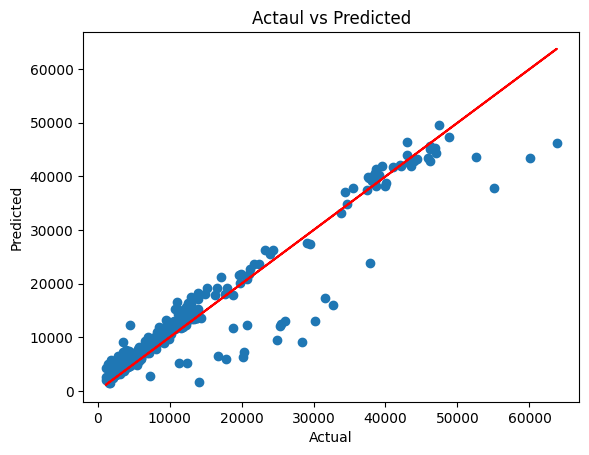

In [33]:
plt.title("Actaul vs Predicted")
plt.scatter(y_test, xgb_pred)
plt.plot(y_test, y_test, color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [36]:
xgb_model_tuned = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
param_dist = {
    "n_estimators": [100, 200, 300, 500, 800, 1000],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma": [0, 0.1, 0.2, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 0.5, 1, 2, 5, 10]
}
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
random_search.fit(x_train, y_train)
print("Best Parameters:")
print(random_search.best_params_)
print("\nBest CV RMSE:")
print(-random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.9}

Best CV RMSE:
4720.016482134283


In [37]:
best_xgb = random_search.best_estimator_

xgb_pred_tuned = best_xgb.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred_tuned))
r2 = r2_score(y_test, xgb_pred_tuned)
print("Test R²:", r2)

Test R²: 0.8960022406953323


In [38]:
print("Model Comparison")
print("="*35)
Model = {
    "Model" : ["XGBoost", "XGBoost Tuned"],
    "r2_score" : [r2_score(y_test, xgb_pred), r2_score(y_test, xgb_pred_tuned)]
}
df = pd.DataFrame(Model)
df.head()

Model Comparison


,Model,r2_score
0,XGBoost,0.898197
1,XGBoost Tuned,0.896002
